In [54]:
from importlib.machinery import SourceFileLoader
import glob
import pandas as pd
import pdb
import matplotlib.pyplot as plt
import numpy as np
import re
np.set_printoptions(precision=3, linewidth=150)
plt.style.use('seaborn')
plt.rc('figure',figsize=(20,12))
plt.rc('axes', labelsize=24)
plt.rc('xtick',labelsize=22)
plt.rc('ytick',labelsize=22)
plt.rc('legend', fontsize=24)
plt.rc('font', size=24)
plt.rc('lines',markersize=10)
# from GetAtomsObjects import BopFoxParser

np.set_printoptions(precision=2, formatter={'float_kind':'{:-6.2f}'.format}, linewidth=120)

#load the function to retrieve raw positions
from PoscarReader import get_raw_positions

import ase

import pickle
from itertools import product

In [2]:
def fix_the_positions(Positions: np.ndarray):
    new_positions = Positions.copy()
    new_positions = np.where(new_positions > 1, new_positions - 1, new_positions)
    new_positions = np.where(new_positions < 0  , new_positions+1, new_positions)
    return new_positions

The following will sort the sublattices in both initial and relaxed poscars/ 

%run SublatticeSorter.py POSCAR.initial

%run GetAtomsObjects.py POSCAR-initial True

%run GetAtomsObjects.py POSCAR-relaxed True

The atoms objects list created should be sorted and ordered already: 

In [3]:
Initial = pd.read_pickle('CrCoW-sorted-POSCAR-initial-noscaled-AtomsObjects.pkl').dropna()
Relaxed = pd.read_pickle('CrCoW-sorted-POSCAR-relaxed-noscaled-AtomsObjects.pkl').dropna()

In [4]:
Relaxed['raw_positions'] = Relaxed['file'].map(lambda s: get_raw_positions(s[0]))

In [5]:
Initial['raw_positions'] = Initial['file'].map(lambda s: get_raw_positions(s[0]))

In [6]:
Initial['raw_positions'] = Initial['raw_positions'].map(fix_the_positions)

In [7]:
Relaxed['raw_positions'][Relaxed.index.str.contains('chi-BABB')&Relaxed.index.str.contains('FM')]#[0].get_scaled_positions() #.map(fix_the_positions).iloc[-1].get_scaled_positions()

index
Co_pv4W_sv25.chi-BABB.FM     [[-0.0, 0.0, -0.0], [0.6382409302609874, 0.638...
Cr_pv4W_sv25.chi-BABB.FM     [[-0.0, 0.0, -0.0], [0.6382409302609874, 0.638...
Cr_pv4Co_pv25.chi-BABB.FM    [[-0.0, 0.0, -0.0], [0.6382409302609874, 0.638...
Name: raw_positions, dtype: object

In [8]:
inboth_index =Initial.index.intersection(Relaxed.index)

In [9]:
inboth_index

Index(['Co_pv6W_sv6.C14-BBA.FM', 'Cr_pv6W_sv2.D0_19-A3B.FM',
       'Cr_pv24W_sv6.sigma-BBAAA.FM', 'Co_pv14W_sv16.sigma-AABAB.FM',
       'Co_pv10W_sv14.C36-ABBBA.FM', 'Cr_pv1Co_pv12W_sv16.chi-ACBC.FM',
       'Co_pv13W_sv16.chi-ABBA.FM', 'Cr_pv22W_sv8.sigma-AAABA.FM',
       'Co_pv4W_sv8.C14-ABB.FM', 'Cr_pv12Co_pv5W_sv12.chi-BBCA.FM',
       ...
       'Cr_pv20W_sv4.C36-ABAAA.FM', 'Cr_pv3W_sv1.L12-A3B.FM',
       'Cr_pv20W_sv4.C36-BAAAA.FM', 'Co_pv10W_sv14.C36-BABAB.FM',
       'Co_pv10W_sv14.C36-ABBAB.FM', 'Co_pv1W_sv1.L10-NiAl-AB.FM',
       'Cr_pv12Co_pv5W_sv12.chi-BBAC.FM', 'Co_pv12W_sv12.C36-BBBAA.FM',
       'Cr_pv24W_sv5.chi-BBAA.FM', 'Co_pv13W_sv16.chi-ABAB.FM'],
      dtype='object', name='index', length=339)

# Volumes after relax

In [10]:
vol_initi = Initial['atoms'].apply(lambda atom: atom.cell.volume)
vol_relax = Relaxed['atoms'].apply(lambda atom: atom.cell.volume)

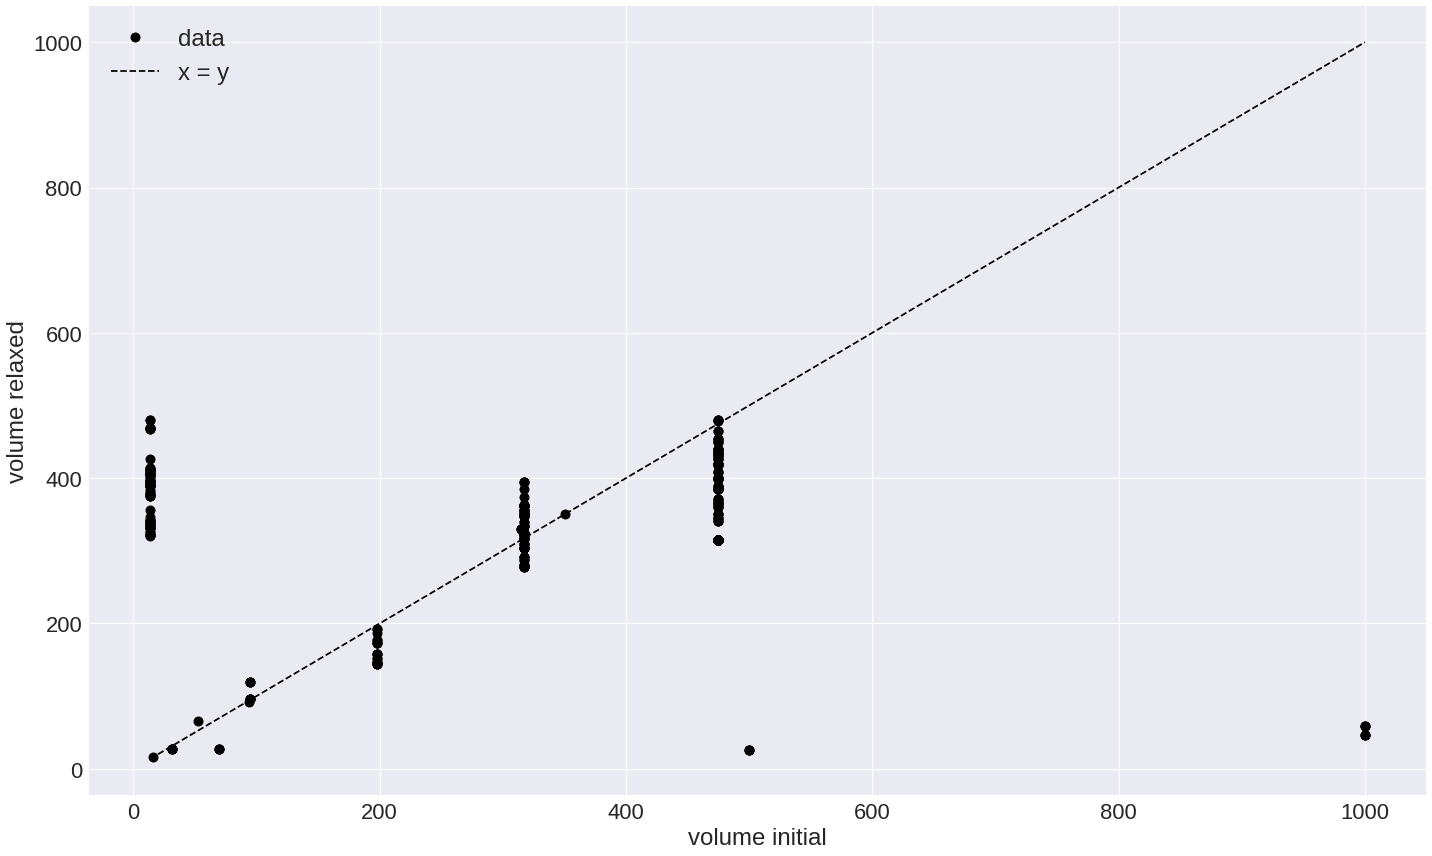

In [11]:
#plt.plot(vol_proto.loc[inboth_index], vol_proto.loc[inboth_index],'--k')
plt.plot(vol_initi.loc[inboth_index], vol_relax.loc[inboth_index],'ok', label='data')
xy = np.linspace(vol_initi.min(), vol_initi.max(),3)
plt.plot(xy,xy,'--k',label='x = y')
plt.legend()
plt.xlabel('volume initial')
plt.ylabel('volume relaxed')
plt.gcf().tight_layout()

#  lets see the files: sublattice

the following loop was replaced by the `SublatticeSorter.py` script

This piece collects the sublattice descriptors from the pposcars file defined in the pandas objects for the initial positions.  Also, negative and greater than 1 positions are corrected

``` python
files = pd.Series(glob.glob('**/POSCAR.initial', recursive=True))

from string import ascii_uppercase

``` python
thisfile = files[files.str.contains('Mo') & files.str.contains('sigma') & files.str.contains('FM')].iloc[7]

thisfile

POSCAR = pd.read_csv(thisfile, sep='\n',dtype='str',header=None)[0]

POSCAR

wheredirect = POSCAR[POSCAR.str.contains('\s*dir|\s*CAR', regex = True)].index.values[0]


wheredirect

BLOCK = []
for SITE in ascii_uppercase:
    BLOCK +=  POSCAR[POSCAR.str.contains(SITE+'$')].index.tolist()
#BLOCK += POSCAR[POSCAR.str.contains('B$')].index.tolist()
#BLOCK += POSCAR[POSCAR.str.contains('C$')].index.tolist()
#BLOCK += POSCAR[POSCAR.str.contains('D$')].index.tolist()
#BLOCK += POSCAR[POSCAR.str.contains('E$')].index.tolist()

type(BLOCK)

thisnspecs = np.fromstring(POSCAR.iloc[5].strip(), sep=' ', dtype=int)

thisnspecs

thissymbs = np.hstack([[x]*thisnspecs[i] for i, x in enumerate(ascii_uppercase[:len(thisnspecs)])])

sorted_symbs = np.array(thissymbs)[np.array(BLOCK)-min(BLOCK)]

type(POSCAR)

sorted_species=[1]
for e in range(1, len(sorted_symbs)):
    if sorted_symbs[e] == sorted_symbs[e-1]:
        sorted_species[-1]+=1
    else:
        sorted_species.append(1)



str(sorted_species)[1:-1].replace(',','')

POSCAR[5] = str(sorted_species).replace(',','').replace('[','').replace(']','')
POSCAR[7:] = POSCAR.iloc[BLOCK]

POSCAR
```

``` python
    Sublattices = {}
    Positions = {}
    for index, fileobj in Initial['file'].iteritems():
        with open(fileobj[0],'r') as f:
            POSCAR_initial = f.readlines()
        wheredirect = [ i for i, line in enumerate(POSCAR_initial) if re.match('\s*dir|\s*CAR', line, re.IGNORECASE) ][0]
        try:   # correct positions out of the box
            POSITIONS = np.vstack([np.fromstring(s.strip(), sep=' ')[:3] for s in POSCAR_initial[wheredirect+1:] if s.strip()!=''])
            POSITIONS = np.where( POSITIONS < 0, POSITIONS +1 , POSITIONS)
            POSITIONS = np.where(POSITIONS > 1, POSITIONS -1, POSITIONS)
            Positions[index] = POSITIONS
        except Exception as E:
            print('Something happened with ')
            pass
        try:
            sublattice = np.array(
                [s.strip().split()[-1] for s in POSCAR_initial[wheredirect+1:] if len(s.strip().split()) > 3  ]
            )
            Sublattices[index] = sublattice
        except Exception as e:
            pdb.set_trace()
            Sublattices[index] = None
            pass
    #    POSCAR_initial_corrected = POSCAR_initial[:wheredirect+1]
    #    POSCAR_initial_corrected[wheredirect-1] = [1]*
    #    thissorter = np.argsort(sublattice)
    #    thisatoms = Initial.loc[index]['atoms']
    #    sorted_symbols = np.array(thisatoms.get_chemical_symbols())[thissorter]
    #    sorted_species=[1]
    #    for e in range(1, len(sorted_symbols)):
    #        if sorted_symbols[e] == sorted_symbols[e-1]:
    #            sorted_species[-1]+=1
    #        else:
    #            sorted_species.append(1)
    #    POSCAR_initial_corrected[wheredirect-1] = ''.join(np.str(sorted_species))[1:-1].replace(',','')+'-'+' '.join(sorted_symbols)+'\n'
    #    POSCAR_initial_corrected[wheredirect+1:]= np.array(POSCAR_initial[wheredirect+1:])[thissorter]
    #    with open('temp/'+index+'.vasp', 'w') as f:
    #        f.writelines(POSCAR_initial_corrected)


    Sublattices = pd.Series(Sublattices)
    Positions = pd.Series(Positions)
    POSCARS = pd.concat((Sublattices, Positions), axis=1)

    SORTERS = Sublattices.dropna().map(np.argsort)

    np.set_printoptions(formatter={'str_kind':'{:5s}'.format,  'float_kind': '{:+4.2f}'.format}, linewidth=500,)

    selection = SORTERS.index.str.contains('FM') & SORTERS.index.str.contains('C14')

    SORTERS_RLX = SORTERS[Relaxed.index]

```
 
 

# Proof tat atoms objects are sorted

In [12]:
Relaxed.columns

Index(['atoms', 'file', 'raw_positions'], dtype='object')

for all the compounds with the same structure, all the positions should have the same indexes in all occurrences

In [13]:
inboth_index

Index(['Co_pv6W_sv6.C14-BBA.FM', 'Cr_pv6W_sv2.D0_19-A3B.FM',
       'Cr_pv24W_sv6.sigma-BBAAA.FM', 'Co_pv14W_sv16.sigma-AABAB.FM',
       'Co_pv10W_sv14.C36-ABBBA.FM', 'Cr_pv1Co_pv12W_sv16.chi-ACBC.FM',
       'Co_pv13W_sv16.chi-ABBA.FM', 'Cr_pv22W_sv8.sigma-AAABA.FM',
       'Co_pv4W_sv8.C14-ABB.FM', 'Cr_pv12Co_pv5W_sv12.chi-BBCA.FM',
       ...
       'Cr_pv20W_sv4.C36-ABAAA.FM', 'Cr_pv3W_sv1.L12-A3B.FM',
       'Cr_pv20W_sv4.C36-BAAAA.FM', 'Co_pv10W_sv14.C36-BABAB.FM',
       'Co_pv10W_sv14.C36-ABBAB.FM', 'Co_pv1W_sv1.L10-NiAl-AB.FM',
       'Cr_pv12Co_pv5W_sv12.chi-BBAC.FM', 'Co_pv12W_sv12.C36-BBBAA.FM',
       'Cr_pv24W_sv5.chi-BBAA.FM', 'Co_pv13W_sv16.chi-ABAB.FM'],
      dtype='object', name='index', length=339)

In [14]:
Relaxed.columns

Index(['atoms', 'file', 'raw_positions'], dtype='object')

In [15]:
selection_rlx = \
    Relaxed.index.str.contains('FM') & \
    Relaxed.index.str.contains('C36') & \
    Relaxed.index.str.contains('^Co_pv')

In [16]:
selection_rlx.any()

True

There are still problems with some phases, a second sorting criteria might be needed

In [17]:
#Relaxed.drop(index='Fe_pv4Mo_sv25.chi-BABB.FM', inplace=True)

In [18]:
for index, sorter in Relaxed[selection_rlx].iterrows():
    print ('{:>10s}\n'.format(index), '{:10s}'.format('rela x   :'), Relaxed['raw_positions'][index][:20,1].ravel())#.get_positions()[:15,0])

Co_pv10W_sv14.C36-ABBBA.FM
 rela x   : [  0.00   0.00   0.00   0.00   0.67   0.33   0.33   0.67   0.67   0.33   0.33   0.67   0.00   0.50   0.50   0.00   0.50
   0.50   0.31   0.85]
Co_pv10W_sv14.C36-BBAAB.FM
 rela x   : [ -0.00  -0.00  -0.00  -0.00   0.67   0.33   0.33   0.67   0.67   0.33   0.33   0.67  -0.00   0.50   0.50  -0.00   0.50
   0.50   0.33   0.84]
Co_pv10W_sv14.C36-BBABA.FM
 rela x   : [  0.00   0.00   0.00   0.00   0.67   0.33   0.33   0.67   0.67   0.33   0.33   0.67   0.00   0.50   0.50   0.00   0.50
   0.50   0.32   0.84]
Co_pv8W_sv16.C36-BAABB.FM
 rela x   : [  0.00   0.00   0.00   0.00   0.67   0.33   0.33   0.67   0.67   0.33   0.33   0.67   0.00   0.50   0.50   0.00   0.50
   0.50   0.33   0.84]
Co_pv6W_sv18.C36-BBBAB.FM
 rela x   : [  0.00   0.00   0.00   0.00   0.67   0.33   0.33   0.67   0.67   0.33   0.33   0.67   0.00   0.50   0.50   0.00   0.50
   0.50   0.33   0.84]
Co_pv4W_sv20.C36-BABBB.FM
 rela x   : [  0.00   0.00   0.00   0.00   0.67   0.33   0.33   0.

In [19]:
selection_rlx =\
    Relaxed.index.str.contains('FM') & \
    Relaxed.index.str.contains('A15') &\
    Relaxed.index.str.contains('^Co_pv')

In [20]:
for index, sorter in Relaxed[selection_rlx].iterrows():
    print ('{:>10s}\n'.format(index), '{:10s}'.format('rela x   :'), Relaxed['raw_positions'][index][:20,1].ravel())#.get_positions()[:15,0])

Co_pv2W_sv6.A15-BA.FM
 rela x   : [  0.00  -0.00   0.25   0.75   0.50   0.50   0.00   0.50]
Co_pv6W_sv2.A15-AB.FM
 rela x   : [ -0.00  -0.00   0.25   0.75   0.50   0.50  -0.00   0.50]


# so lets sort them all 

This is not necesary any more, but the following code would have made the work if starting from the existing atoms objects. reading the poscars would still be necesary as sublattice info is saved there.

``` python
Initial['atoms'][selection].apply(lambda atom: atom.get_scaled_positions().ravel())

Relaxed['sorters'] = SORTERS

Initial['sorters'] = SORTERS

for index, compound in Initial.iterrows():
    positions = compound['atoms'].get_scaled_positions()
    positions = np.where(positions > 1, positions -1 , positions)
    positions = np.where(positions < 0, positions +1 , positions)
    symbols =  np.array(compound['atoms'].get_chemical_symbols())
    try:
        compound['atoms'].set_chemical_symbols(symbols[compound['sorters']])
        compound['atoms'].set_scaled_positions(positions[compound['sorters']])
    except ValueError as E:
        pass
    compound['atoms'].write('temp/'+index+'-init.vasp', format='vasp')
#    compound['atoms'].set_scaled_positions(positions[sorter])
#    compound['atoms'].set_chemical_symbols(symbols[sorter])

for index, compound in Relaxed.iterrows():
    positions = compound['atoms'].get_scaled_positions()
    symbols =  np.array(compound['atoms'].get_chemical_symbols())
    try:
        compound['atoms'].set_chemical_symbols(symbols[compound['sorters']])
        compound['atoms'].set_scaled_positions(positions[compound['sorters']])
    except ValueError as E:
        pass
    compound['atoms'].write('temp/'+index+'-relax.vasp', format='vasp')
#    compound['atoms'].set_scaled_positions(positions[sorter])
#    compound['atoms'].set_chemical_symbols(symbols[sorter])

Relaxed['atoms'][selection_rlx].apply(lambda atom: atom.get_scaled_positions().ravel())

for index, compound in Initial.iterrows():
    positions = Initial['atoms'][index].get_scaled_positions()
    Initial['atoms'][index].set_scaled_positions(positions)
```

# The parsed data:

this is necesary in my setup as it makes it easy to filter by composition. The composition of each strucure is read from briefsumaries but can also be parsed from file names. To make it work , one needs my version of Bopfox featurizers. The `parsed` variable is created in `GetAtomsObjects.py` and saved as a pickle that we need to pick

In [21]:
from BopFoxFeaturizer.brief_summary_parser import irregular_file_parser, StructSummaryParser
from BopFoxFeaturizer.parsers import BopFoxParser

with open('parsed_briefsummaries.pkl','rb') as f:
    Parsed = pickle.load(f)

# Binaries 

In [22]:
indexes = Parsed.data.index

In [23]:
BinariesCoW = Parsed.data[ (Parsed.data['nelem']==2).values & Parsed.data.index.str.contains('W_sv')&  Parsed.data.index.str.contains('Co_pv') ]

In [24]:
BinariesCrW = Parsed.data[ (Parsed.data['nelem']==2).values & Parsed.data.index.str.contains('Cr')&  Parsed.data.index.str.contains('W') ]

In [25]:
BinariesCrCo = Parsed.data[ (Parsed.data['nelem']==2).values & Parsed.data.index.str.contains('Cr')&  Parsed.data.index.str.contains('Co') ]

In [26]:
BinariesCoW

,,B,E0,V,deltak,encut,fit,ncrash,nelem,xc,atom_A,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C
index,,,,,,,,,,,,,,,,
Co_pv6W_sv6.C14-BBA.FM,bulk C14-BBA.FM,293.907391,-10.000427,13.175678,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,Co_pv,W_sv,,6,6,0
Co_pv14W_sv16.sigma-AABAB.FM,bulk sigma-AABAB.FM,266.695412,-10.041010,13.677885,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,Co_pv,W_sv,,14,16,0
Co_pv10W_sv14.C36-ABBBA.FM,bulk C36-ABBBA.FM,242.509246,-10.058736,14.633975,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,Co_pv,W_sv,,10,14,0
Co_pv13W_sv16.chi-ABBA.FM,bulk chi-ABBA.FM,261.218338,-10.105443,13.780334,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,Co_pv,W_sv,,13,16,0
Co_pv4W_sv8.C14-ABB.FM,bulk C14-ABB.FM,973.672196,-10.135609,16.334567,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,Co_pv,W_sv,,4,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Co_pv10W_sv14.C36-BABAB.FM,bulk C36-BABAB.FM,228.541396,-9.940928,14.882561,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,Co_pv,W_sv,,10,14,0
Co_pv10W_sv14.C36-ABBAB.FM,bulk C36-ABBAB.FM,227.407495,-9.945161,14.986230,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,Co_pv,W_sv,,10,14,0
Co_pv1W_sv1.L10-NiAl-AB.FM,bulk L10-NiAl-AB.FM,279.848905,-9.945921,13.181972,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,Co_pv,W_sv,,1,1,0


In [27]:
XW_binariesCoW = BinariesCoW['num_atom_B']/BinariesCoW[['num_atom_A','num_atom_B']].sum(axis=1)

In [28]:
XW_binariesCoW

index
Co_pv6W_sv6.C14-BBA.FM               0.5
Co_pv14W_sv16.sigma-AABAB.FM    0.533333
Co_pv10W_sv14.C36-ABBBA.FM      0.583333
Co_pv13W_sv16.chi-ABBA.FM       0.551724
Co_pv4W_sv8.C14-ABB.FM          0.666667
                                  ...   
Co_pv10W_sv14.C36-BABAB.FM      0.583333
Co_pv10W_sv14.C36-ABBAB.FM      0.583333
Co_pv1W_sv1.L10-NiAl-AB.FM           0.5
Co_pv12W_sv12.C36-BBBAA.FM           0.5
Co_pv13W_sv16.chi-ABAB.FM       0.551724
Length: 76, dtype: object

# Exploration of binaries

In [29]:
binaries = [('Cr','Co','^W'), ('Co','W','^Cr'), ('Cr','W','^Co')]

In [30]:
phases = Parsed.StrucNames.unique()

In [48]:
phases = ['C14','sigma', 'chi', 'A15']
mags = ['FM']#,'NM']

In [34]:
#TheBinaries = Parsed.data[Parsed.data['nelem'] == 2 ]
TheRelaxedData = Parsed.data.loc[Relaxed.index]
TheBinariesRelaxed = TheRelaxedData[TheRelaxedData['nelem']==2]

In [35]:
phases

['C14', 'sigma', 'chi', 'A15']

In [56]:
def dothemeans(_XB, _TheBinaryRelaxedPositions):
    xs = np.sort(_XB.unique())
    stds = []
    means = []
    for x in xs: 
        selection = np.abs(_XB - x) < 1e-3
        if any(selection):
            thispositions = _TheBinaryRelaxedPositions[selection]['raw_positions']
            stds.append(thispositions.values.std())
            means.append(thispositions.values.mean())
    return xs, means, stds

stds = {}
means = {}
xs  = {}
for thisbin, thisphase, thismag in product(binaries, phases, mags):
    # TheBinariesRelaxed.index.str.contains(thisbin[-1]) &
    TheBinaryRelaxed = TheBinariesRelaxed[ 
         TheBinariesRelaxed['atom_B'].str.contains(thisbin[1]) &
        TheBinariesRelaxed.index.str.contains(thisphase) & TheBinariesRelaxed.index.str.contains(thismag)
    ]
    TheBinaryRelaxedPositions = Relaxed.loc[TheBinaryRelaxed.index]
    XB = TheBinaryRelaxed['num_atom_A']/TheBinaryRelaxed[['num_atom_A','num_atom_B']].sum(axis=1)
    thekey = ''.join(thisbin[:-1])+'-'+thisphase+'.'+thismag
    xs[thekey], means[thekey], stds[thekey] = dothemeans(XB, TheBinaryRelaxedPositions)
#    thex, themeans, thestds = makepossds(XB, 'A15', 'FM')
    #TheFMBinaryRelaxedPositions = TheBinariesRelaxed.loc[ TheBinariesRelaxed.index.str.contains(thisbin[-1]) & TheBinariesRelaxed.index.str.contains('FM') ] 
    #XB = TheBinaryRelaxedPositions['num_atom_A']

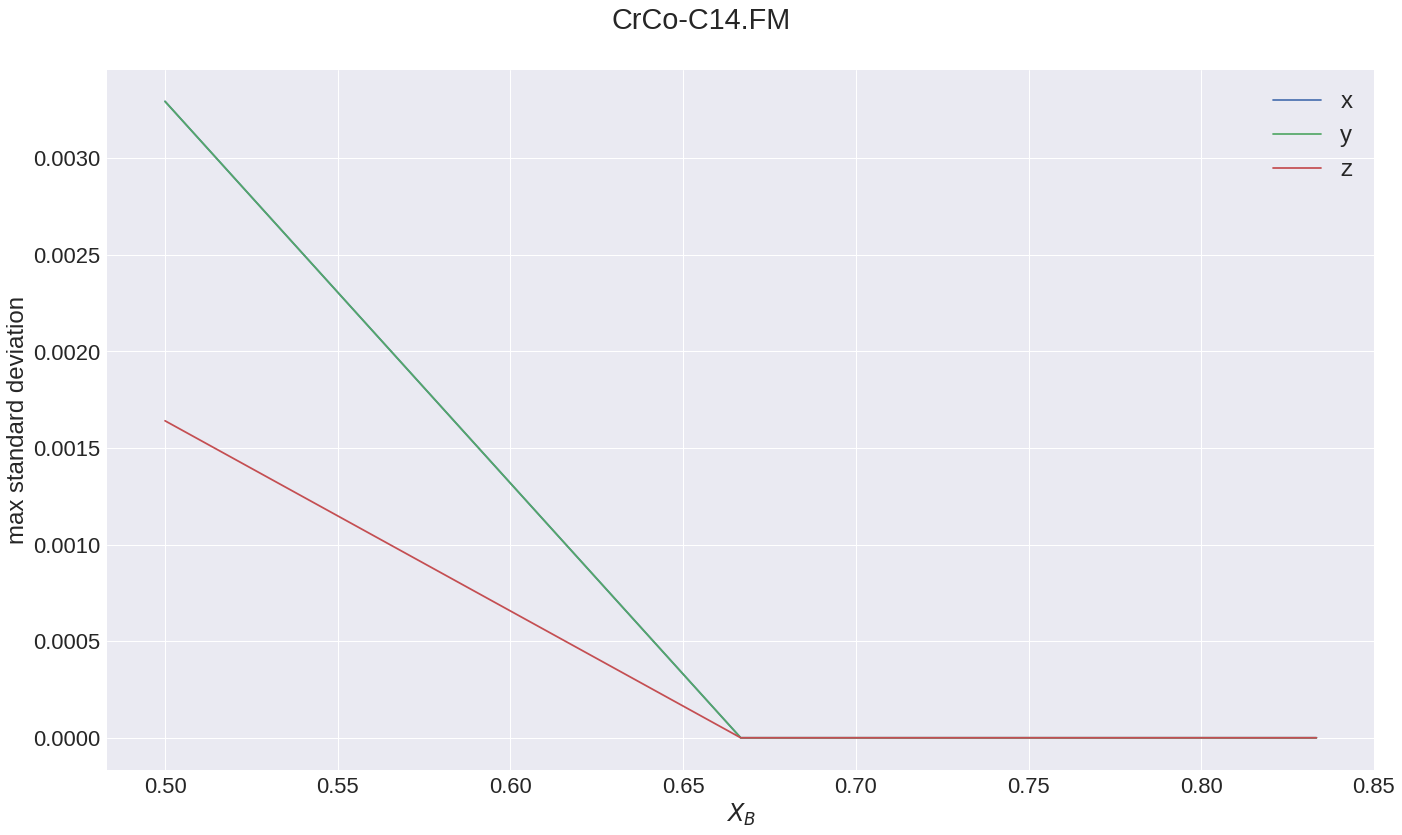

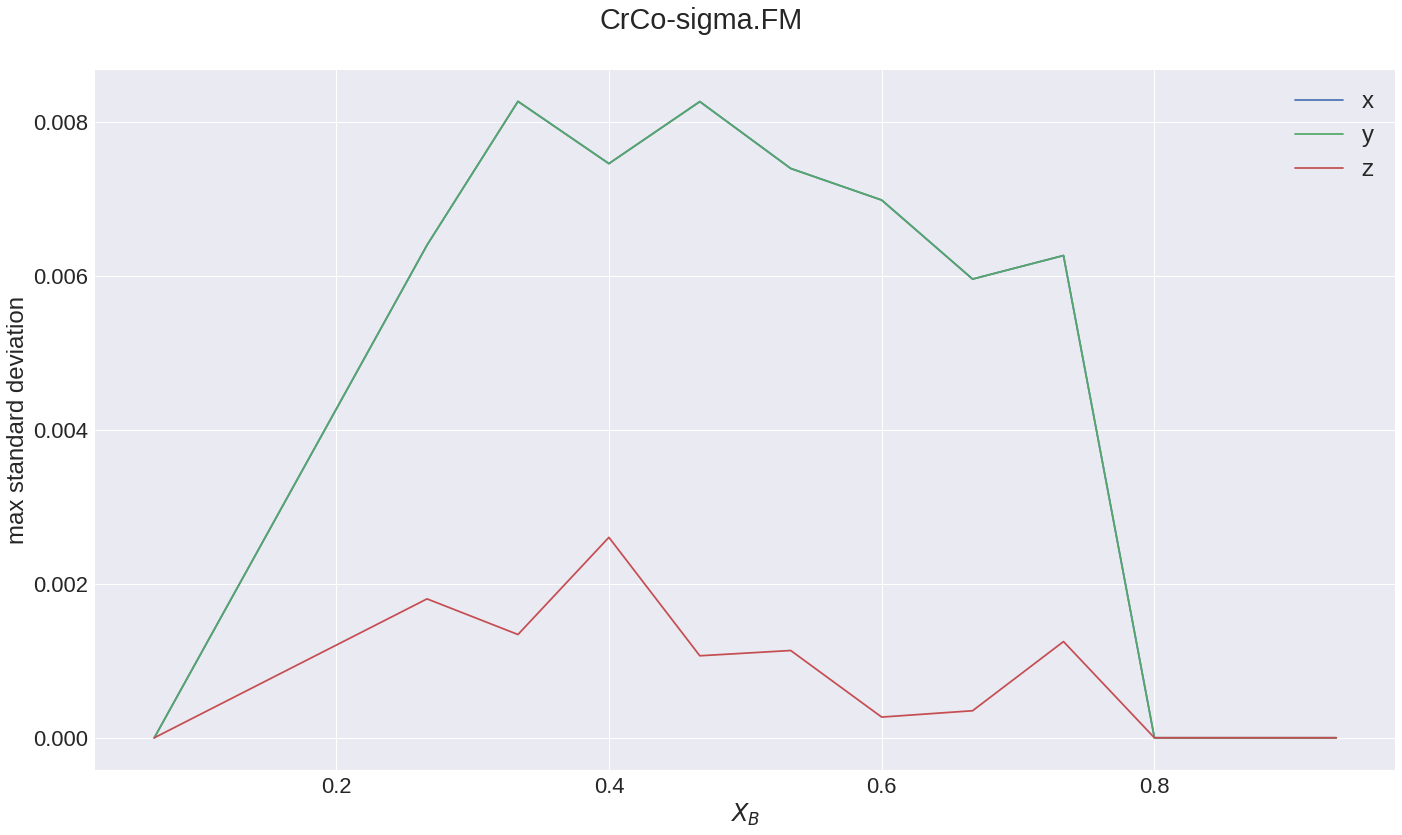

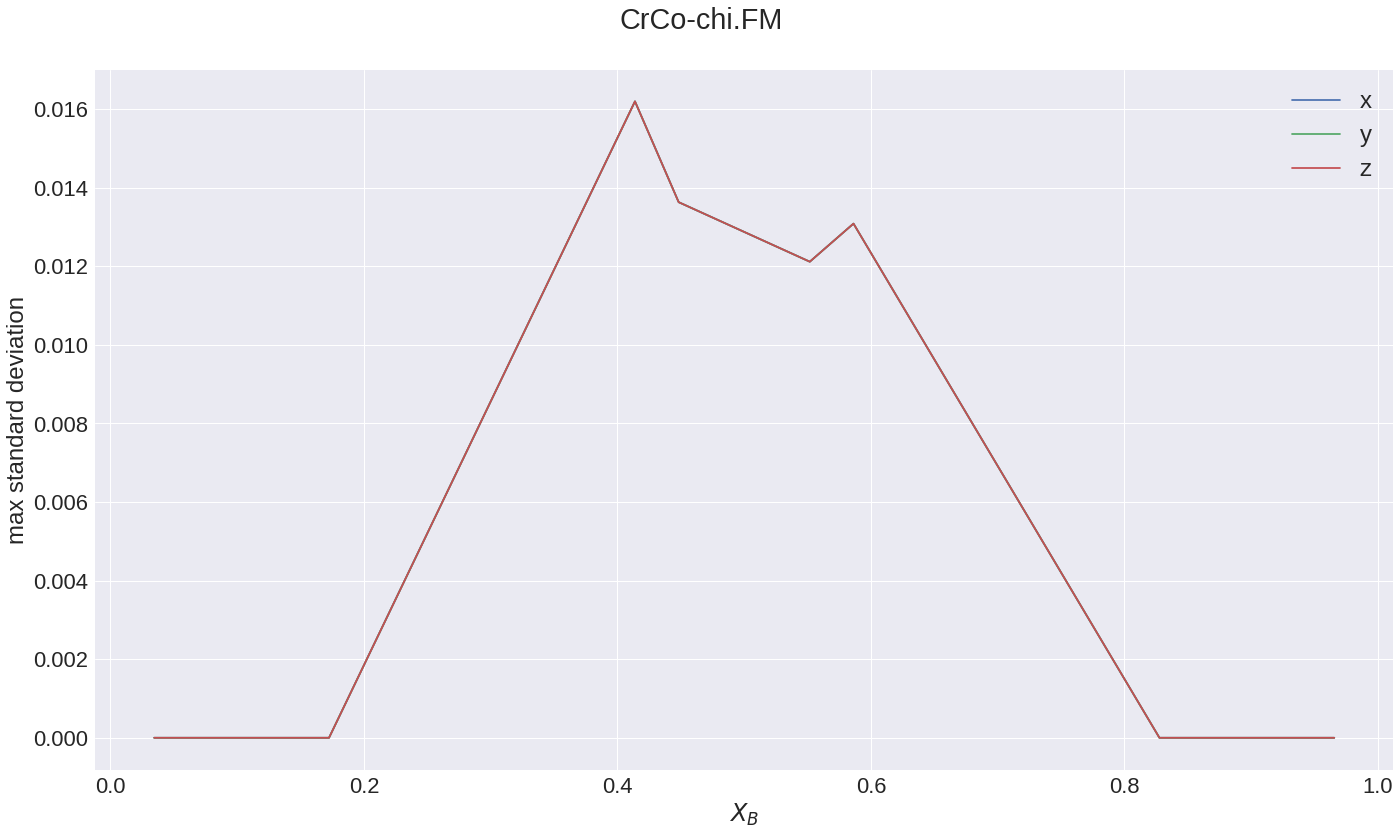

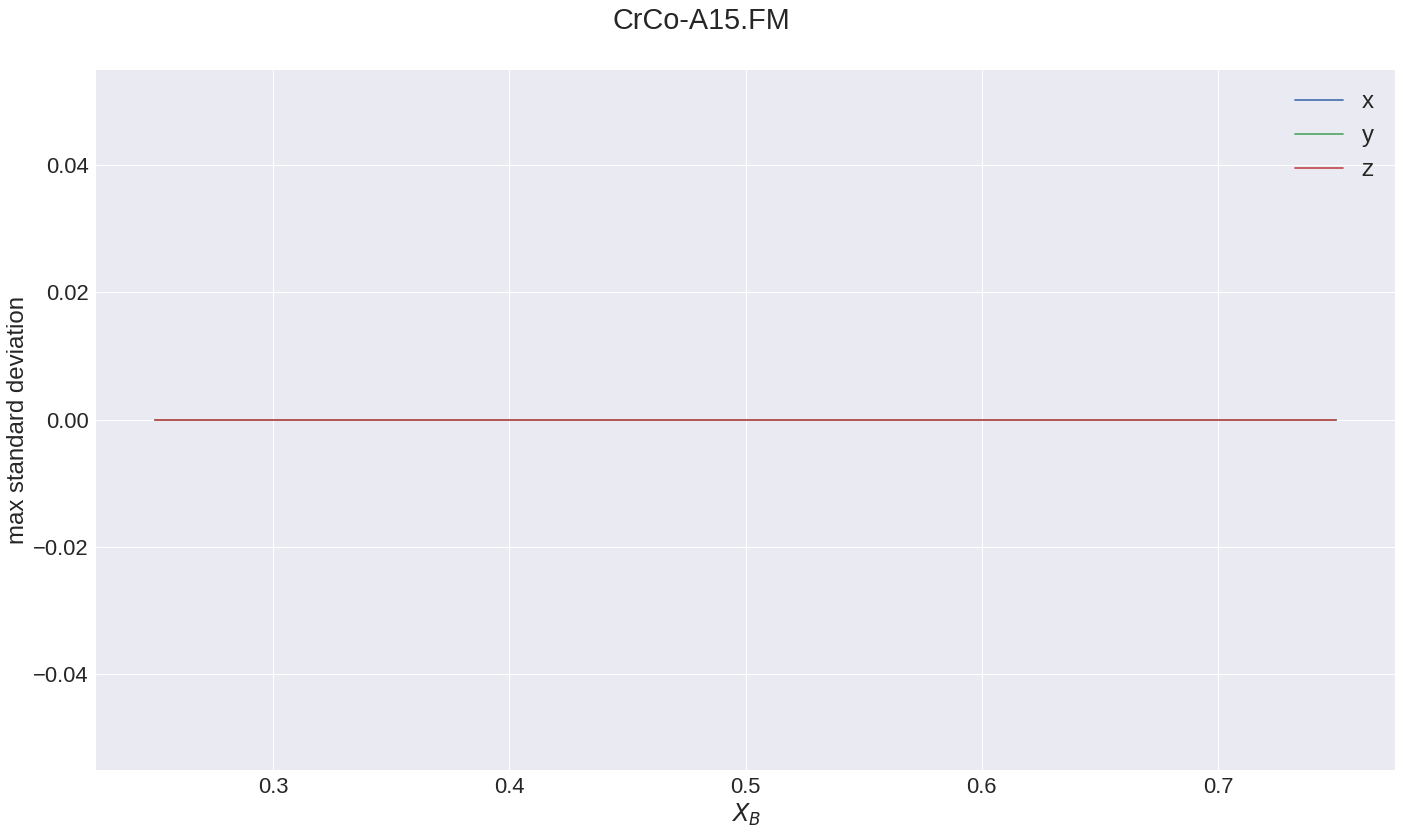

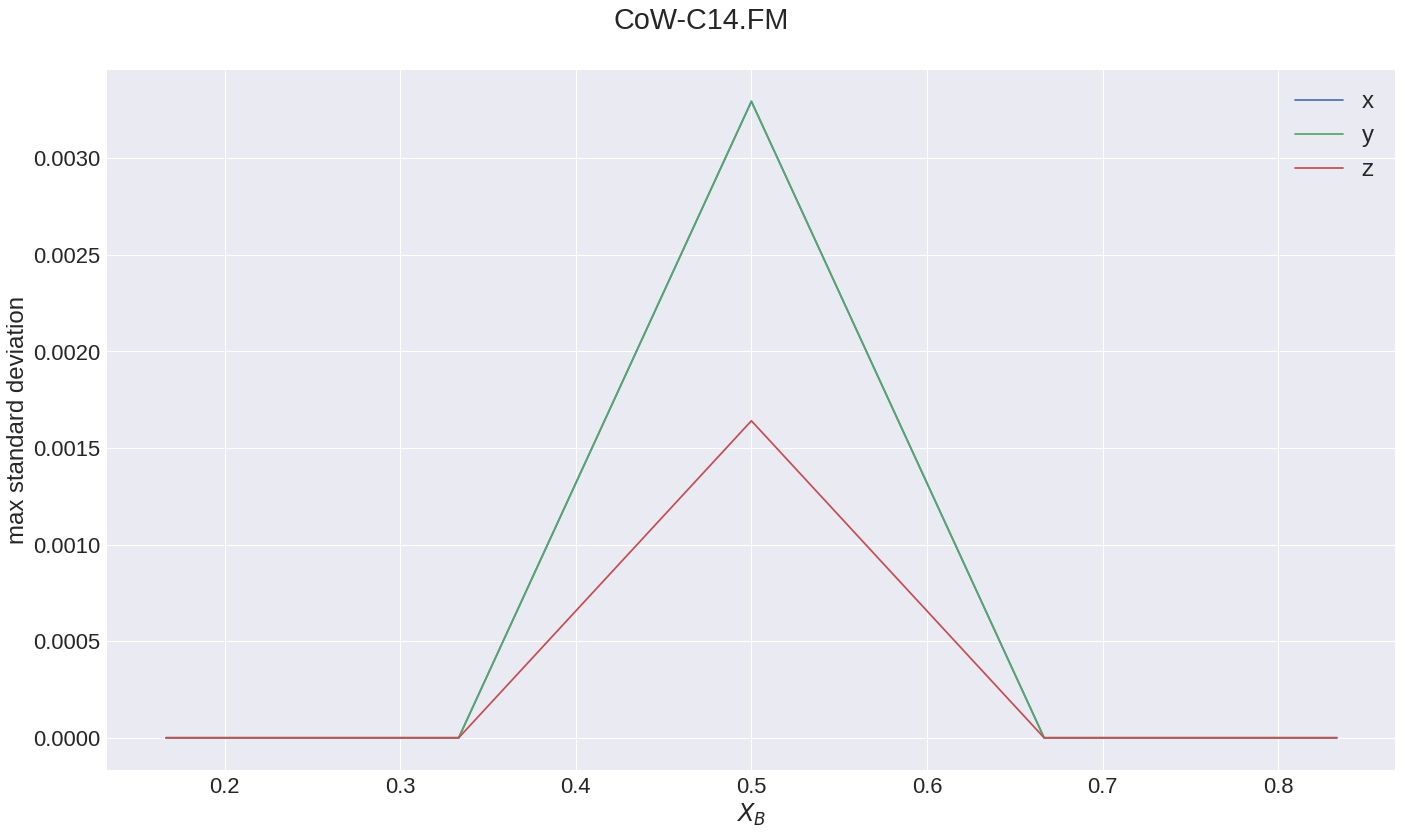

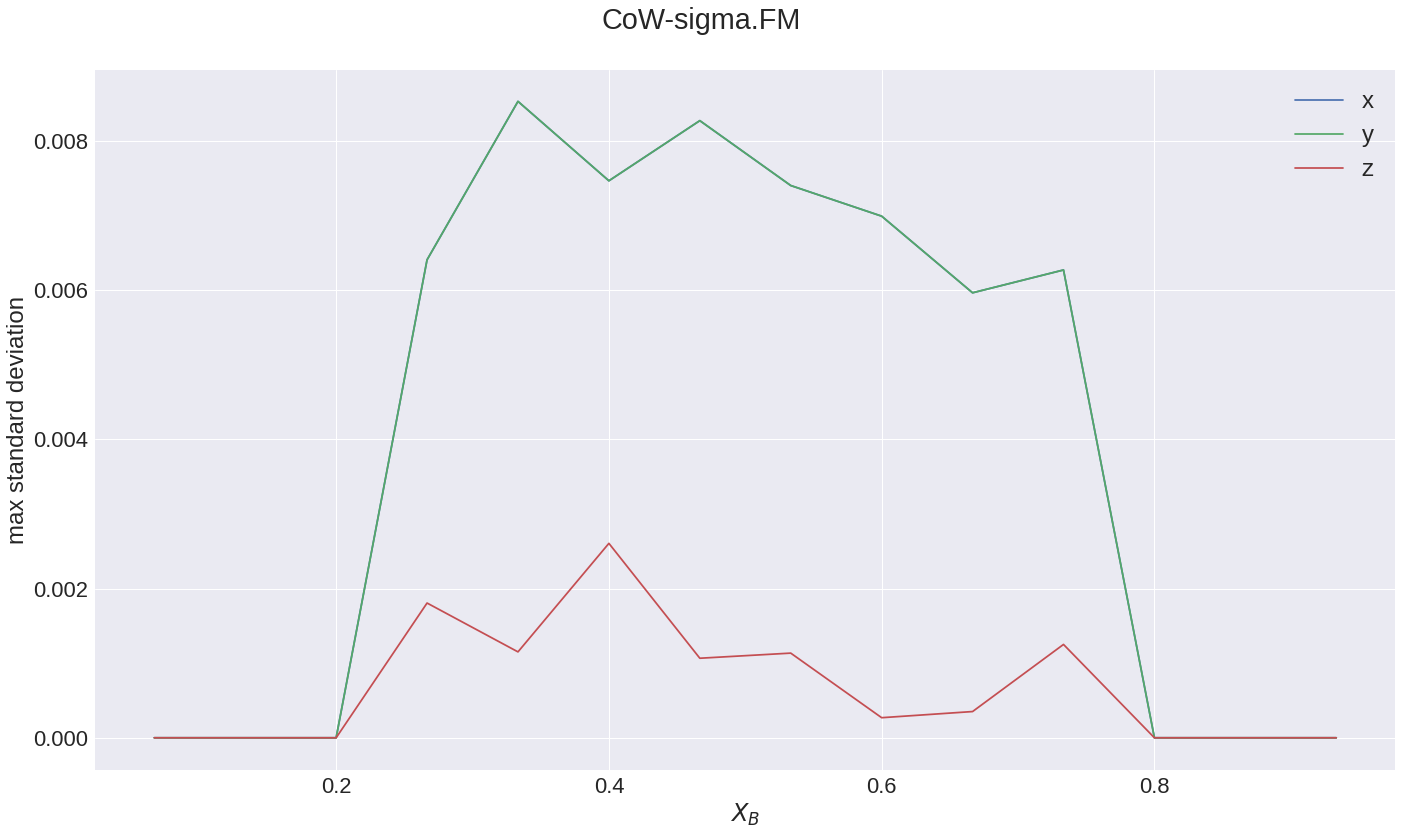

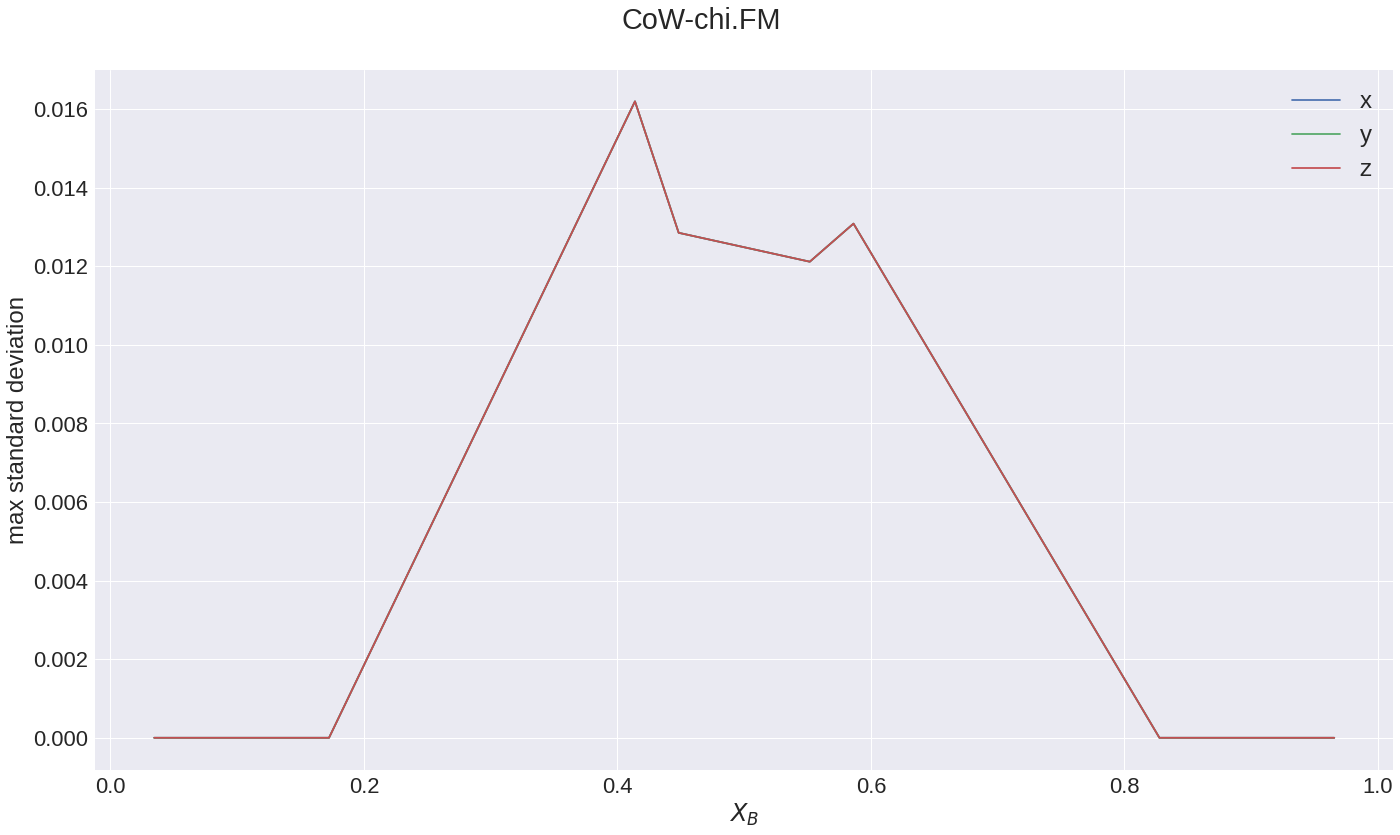

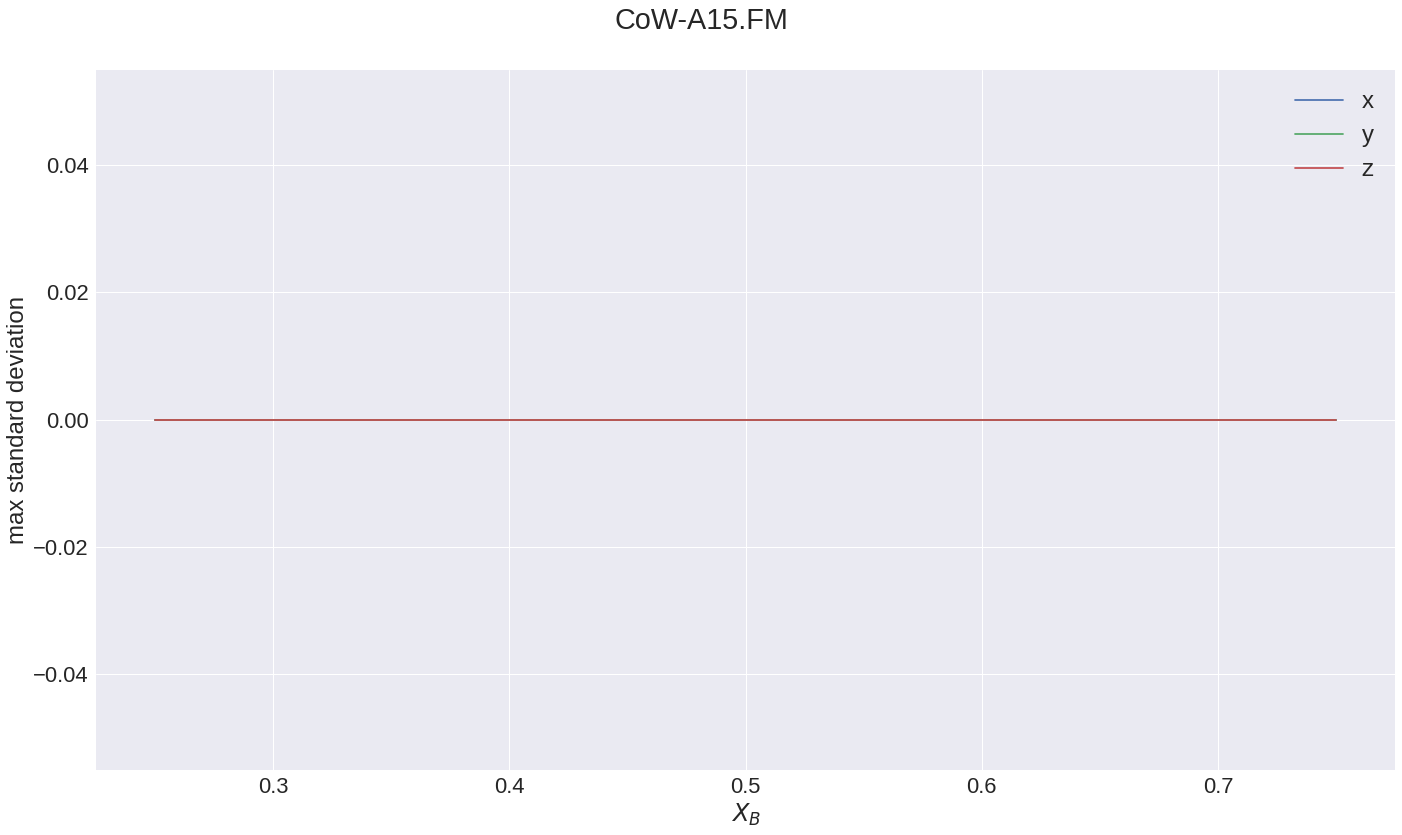

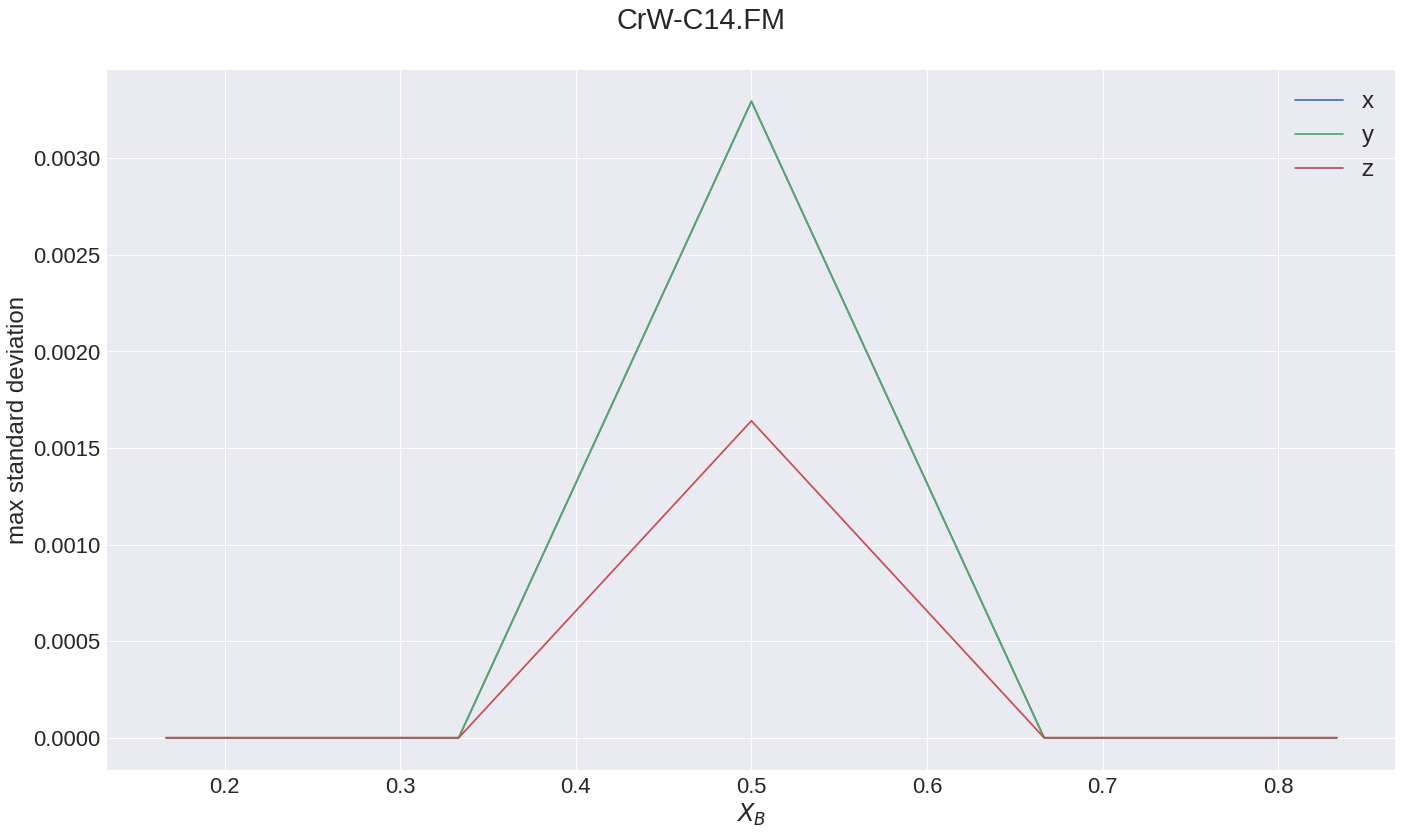

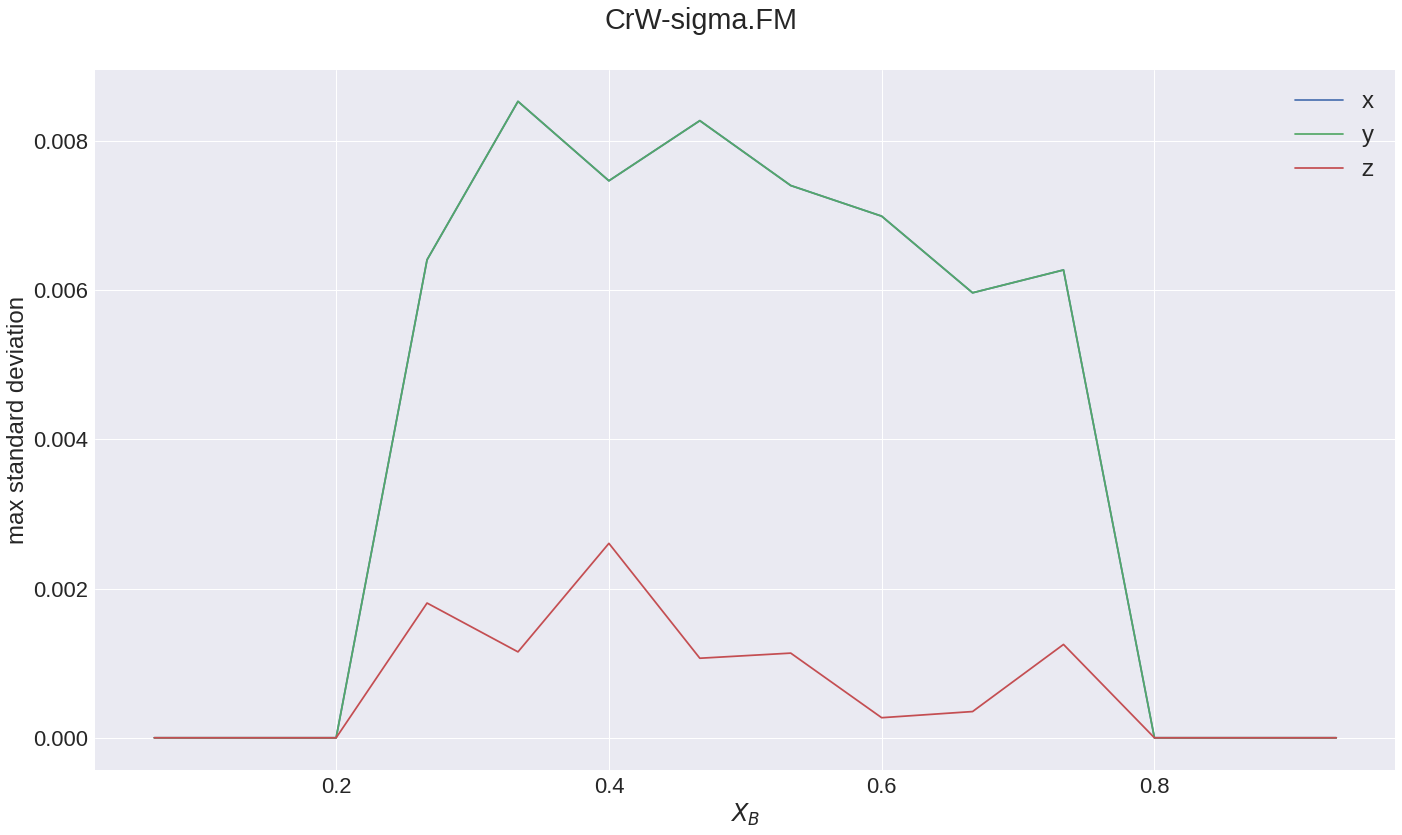

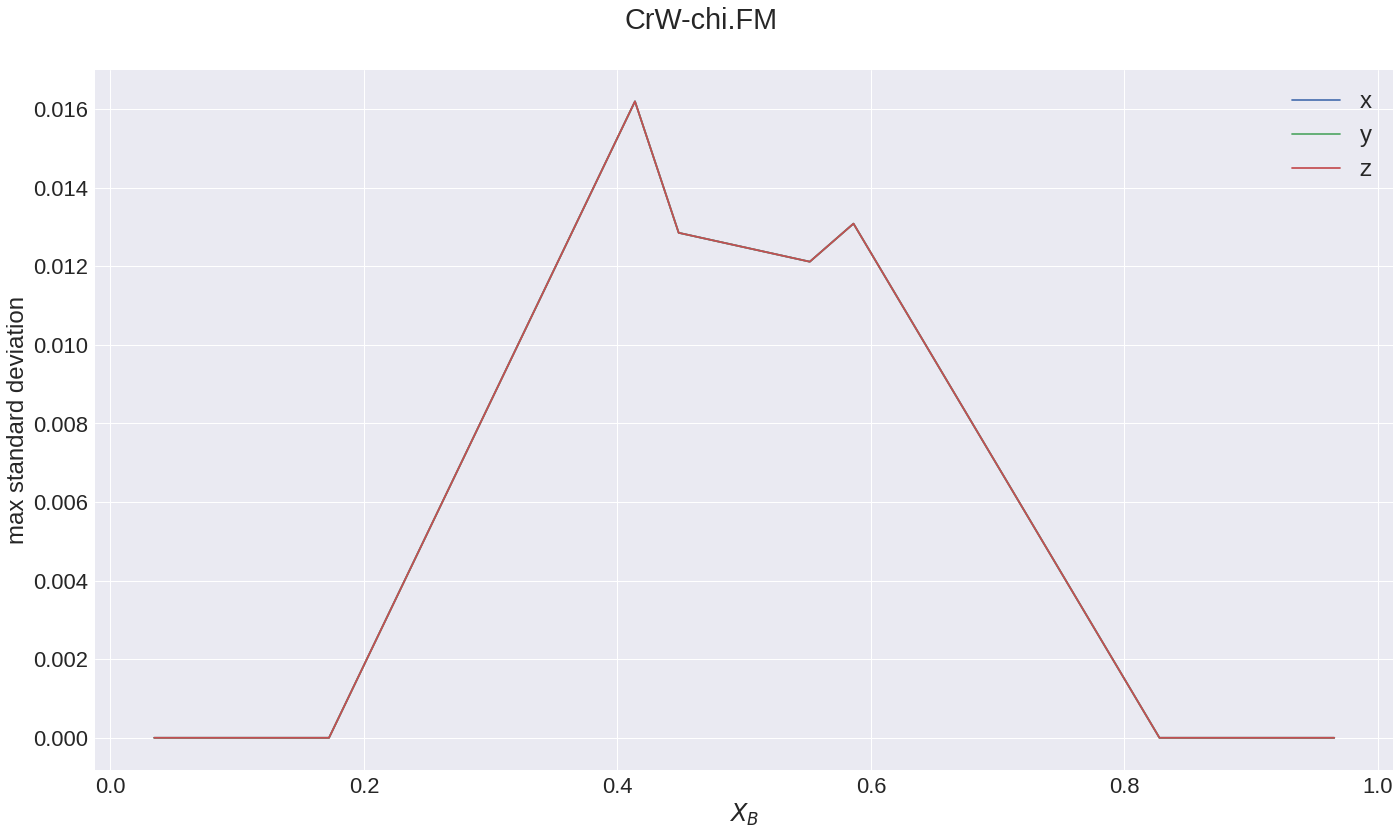

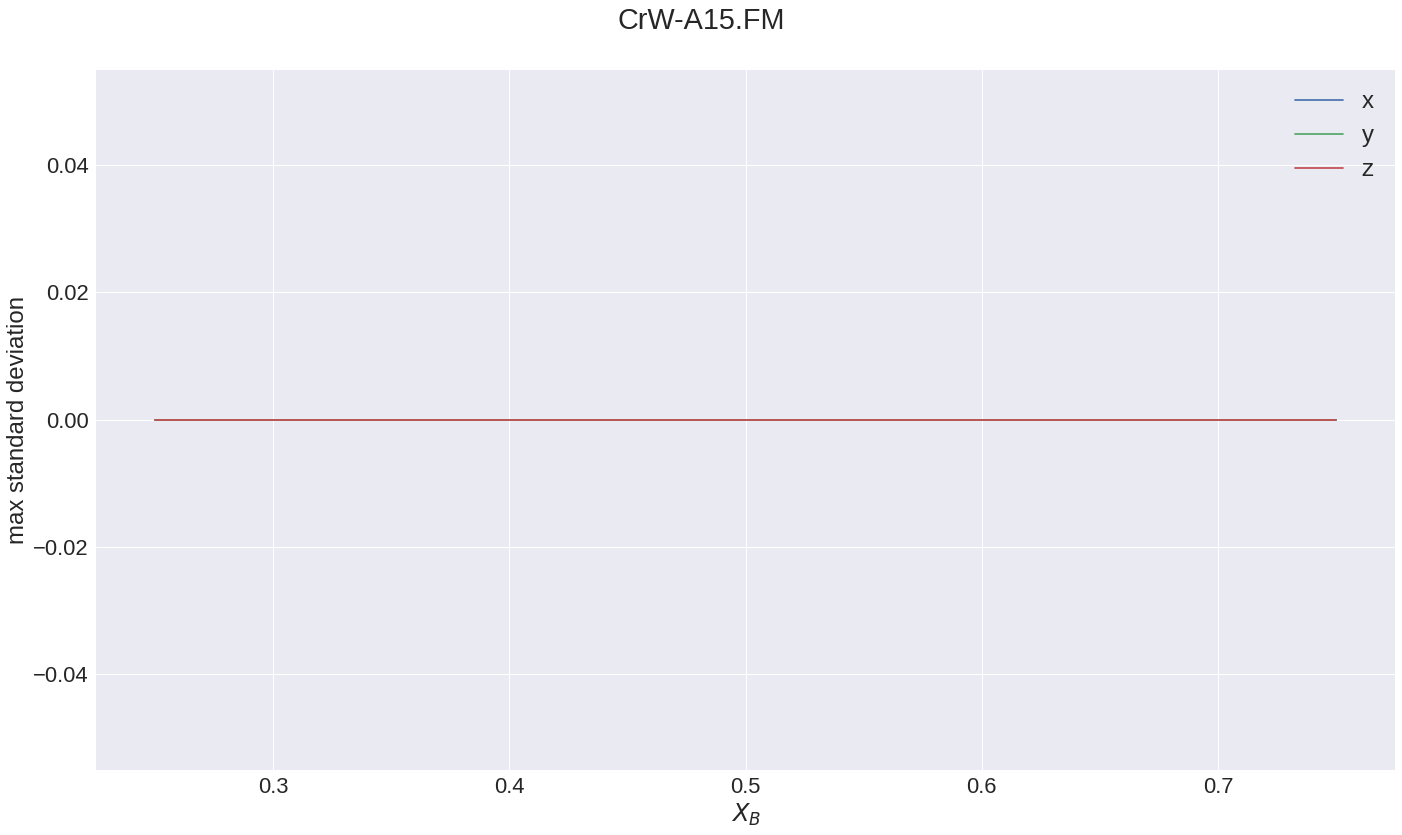

In [58]:
for key in xs.keys():
    stdevol = np.array([std.max(axis=0) for std in stds[key]])
    fig = plt.figure()
    plt.suptitle(key+')
    plt.plot(xs[key],stdevol)
    plt.xlabel('$X_B$')
    plt.ylabel('max standard deviation')
    plt.legend(['x','y','z'])
    fig.tight_layout()

In [237]:
means

{'CrCo': [], 'CoW': [], 'CrW': []}

In [223]:
stds

{'CoCr': [], 'CoW': [], 'CrW': []}

In [182]:
phases

array(['C14', 'D0_19', 'sigma', 'C36', 'chi', 'A15', 'hcp', 'L10', 'B2', 'L12', 'fcc', 'bcc', 'sigma_Co_pv',
       'sigma_Cr_pv'], dtype=object)

In [161]:
with np.printoptions(precision=2, formatter={'float_kind':'{:-6.2f}'.format}, linewidth=300):
    print('x: -------------------')
    [print(xyz[:,0]) for xyz in means['CoW']]
    print('y: -------------------')
    [print(xyz[:,1]) for xyz in means['CoW']]
    print('z: -------------------')
    [print(xyz[:,1]) for xyz in means['CoW']]

x: -------------------
[ -0.00  -0.00  -0.00  -0.00   0.33   0.67   0.67   0.33   0.33   0.67   0.67   0.33   0.50  -0.00   0.50   0.50  -0.00   0.50   0.16   0.68   0.16   0.84   0.32   0.84]
[ -0.00  -0.00  -0.00  -0.00   0.33   0.67   0.67   0.33   0.33   0.67   0.67   0.33   0.50  -0.00   0.50   0.50  -0.00   0.50   0.16   0.68   0.16   0.84   0.32   0.84]
[  0.00   0.00   0.00   0.00   0.33   0.67   0.67   0.33   0.33   0.67   0.67   0.33   0.50   0.00   0.50   0.50   0.00   0.50   0.16   0.68   0.16   0.84   0.32   0.84]
[  0.00   0.00   0.00   0.00   0.33   0.67   0.67   0.33   0.33   0.67   0.67   0.33   0.50   0.00   0.50   0.50   0.00   0.50   0.16   0.68   0.16   0.84   0.32   0.84]
[  0.00   0.00   0.00   0.00   0.33   0.67   0.67   0.33   0.33   0.67   0.67   0.33   0.50   0.00   0.50   0.50   0.00   0.50   0.16   0.67   0.16   0.84   0.33   0.84]
[  0.00   0.00   0.00   0.00   0.33   0.67   0.67   0.33   0.33   0.67   0.67   0.33   0.50   0.00   0.50   0.50   0.00   0.50 

<AxesSubplot:>

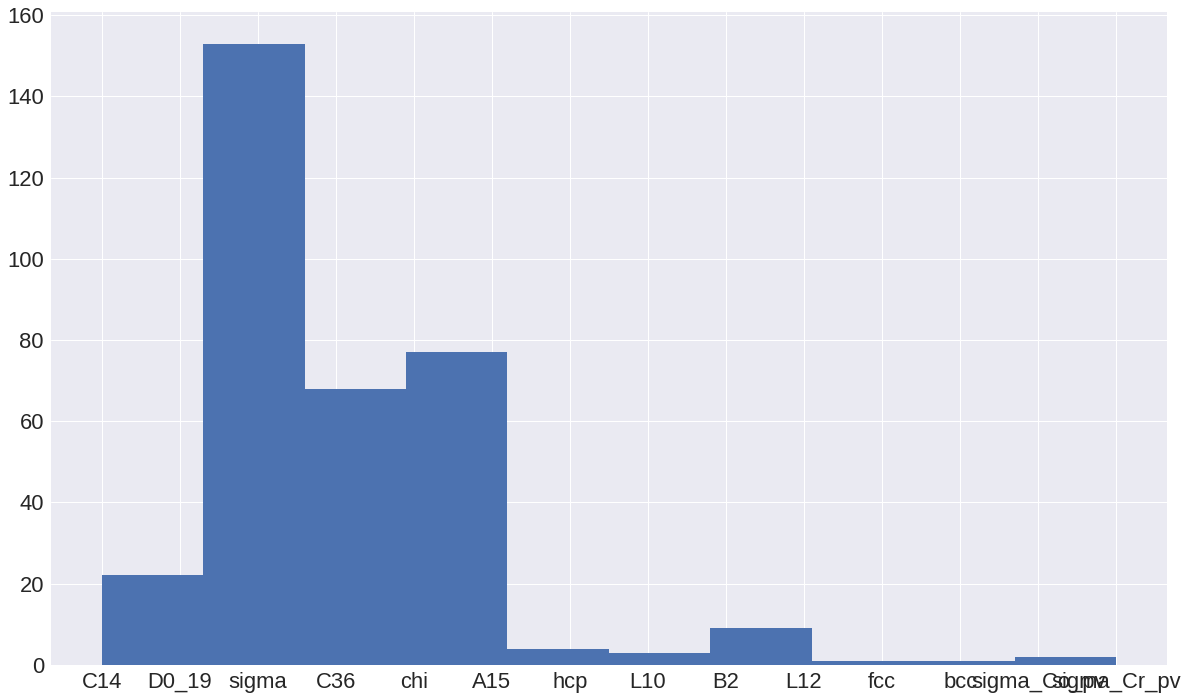

In [59]:
Parsed.StrucNames.hist()